# Hyperparameter Tuning with Optuna

**Docker image**: `ml4t`

**Chapter 12, Section 12.4**: Advanced Hyperparameter Tuning with Optuna

## Purpose
This notebook demonstrates efficient hyperparameter optimization using Optuna's
Bayesian optimization framework with TPE on the ETF case study. It covers
single-fold tuning with pruning and early stopping, then extends to averaged
walk-forward HPO — the recommended approach for financial data.

## Learning Objectives
After completing this notebook, you will be able to:
- Apply Optuna's define-by-run API to tune LightGBM hyperparameters
- Use early stopping and MedianPruner to reduce wasted computation
- Implement time-series-aware tuning with averaged walk-forward evaluation
- Interpret hyperparameter importance rankings
- Compare default vs tuned model performance on held-out data

## Cross-References
- **Section 12.4**: TPE, pruning, GBM tuning strategy, time-series-aware tuning
- **Related**: `07_hpo_comparison` (grid vs Optuna), `06_optuna_multi_asset` (multi-objective)

## 1. Setup

In [1]:
"""Hyperparameter Tuning with Optuna — demonstrate TPE-based optimization with pruning for GBMs."""

import time
import warnings
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl

warnings.filterwarnings("ignore")

import lightgbm as lgb
import optuna
from lightgbm import LGBMRegressor
from ml4t.diagnostic.metrics import cross_sectional_ic_series
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler


def cross_sectional_ic_mean(y_true, y_pred, dates, symbols):
    pred_df = pl.DataFrame({"timestamp": dates, "symbol": symbols, "prediction": y_pred})
    ret_df = pl.DataFrame({"timestamp": dates, "symbol": symbols, "forward_return": y_true})
    ic_per_date = cross_sectional_ic_series(
        pred_df,
        ret_df,
        pred_col="prediction",
        ret_col="forward_return",
        date_col="timestamp",
        entity_col="symbol",
    )
    ic_clean = ic_per_date.drop_nulls("ic")
    return float(ic_clean["ic"].mean()) if ic_clean.height else float("nan")


from utils.cv_splits import load_evaluation_config
from utils.modeling import load_modeling_dataset
from utils.reproducibility import set_global_seeds
from utils.style import COLORS

optuna.logging.set_verbosity(optuna.logging.WARNING)

In [2]:
N_TRIALS = 50
MAX_FOLDS = 0  # 0 = all folds for walk-forward HPO
SEED = 42

In [3]:
set_global_seeds(SEED)

## 2. Load ETF Features

In [4]:
mds = load_modeling_dataset("etfs", "fwd_ret_21d")
df = mds.dataset.to_pandas()
date_col = mds.date_col
FEATURE_COLS = mds.feature_names

n_folds = len(mds.splits)
if MAX_FOLDS > 0:
    n_folds = min(n_folds, MAX_FOLDS)

# The TEST set is the case study's sealed holdout (setup.yaml `holdout_start` /
# `holdout_end`). All eight walk-forward folds live strictly BEFORE holdout_start,
# so the entire Optuna search — single-fold AND averaged walk-forward — is
# confined to the selection region and never touches the holdout. This is the
# invariant that makes the "acid test" on the held-out fold legitimate.
eval_cfg = load_evaluation_config("etfs")
holdout_start = pd.Timestamp(eval_cfg["holdout_start"])
holdout_end = pd.Timestamp(eval_cfg["holdout_end"])
LABEL_HORIZON = 21  # trading days — fwd_ret_21d

# Embargo: trim any validation date whose 21-trading-day label horizon would
# reach into the holdout, so early stopping never observes a return realized on
# or after the first holdout day. A fwd_ret_21d label at date d is realized 21
# trading days later, so the last admissible val date must have at least 21
# trading days BEFORE holdout_start — i.e. index -(LABEL_HORIZON + 1) into the
# pre-holdout calendar (the -LABEL_HORIZON date lands on the first holdout day).
# Only the fold adjacent to holdout_start (fold 0) is affected; earlier folds end
# well before the cutoff.
pre_holdout_dates = np.sort(df.loc[df[date_col] < holdout_start, date_col].unique())
val_embargo_cutoff = pd.Timestamp(pre_holdout_dates[-(LABEL_HORIZON + 1)])

# Single-fold demo uses the most recent walk-forward fold (fold 0); validation is
# fold 0's val window trimmed by the embargo cutoff above.
split0 = mds.splits[0]

train_mask = (df[date_col] >= split0["train_start"]) & (df[date_col] <= split0["train_end"])
val_end = min(pd.Timestamp(split0["val_end"]), val_embargo_cutoff)
val_mask = (df[date_col] >= split0["val_start"]) & (df[date_col] <= val_end)
test_mask = (df[date_col] >= holdout_start) & (df[date_col] <= holdout_end)

primary_entity_col = mds.entity_cols[0]

X_train = df.loc[train_mask, FEATURE_COLS].values
y_train = df.loc[train_mask, mds.label_col].values
X_val = df.loc[val_mask, FEATURE_COLS].values
y_val = df.loc[val_mask, mds.label_col].values
X_test = df.loc[test_mask, FEATURE_COLS].values
y_test = df.loc[test_mask, mds.label_col].values
dates_val = df.loc[val_mask, date_col].values
symbols_val = df.loc[val_mask, primary_entity_col].values
dates_test = df.loc[test_mask, date_col].values
symbols_test = df.loc[test_mask, primary_entity_col].values

# Drop NaN labels
valid = np.isfinite(y_train)
X_train, y_train = X_train[valid], y_train[valid]
valid = np.isfinite(y_val)
X_val, y_val = X_val[valid], y_val[valid]
dates_val, symbols_val = dates_val[valid], symbols_val[valid]
valid = np.isfinite(y_test)
X_test, y_test = X_test[valid], y_test[valid]
dates_test, symbols_test = dates_test[valid], symbols_test[valid]

print(f"ETFs: {len(FEATURE_COLS)} features, N_TRIALS: {N_TRIALS}")
print(f"Train: {len(X_train):,}, Val: {len(X_val):,}, Test (sealed holdout): {len(X_test):,}")
print(f"Holdout window: {holdout_start.date()} → {holdout_end.date()}")
print(f"Walk-forward folds available: {len(mds.splits)} (using {n_folds})")

ETFs: 71 features, N_TRIALS: 50
Train: 227,101, Val: 22,174, Test (sealed holdout): 44,733
Holdout window: 2024-01-01 → 2025-12-31
Walk-forward folds available: 8 (using 8)


## 3. LightGBM Hyperparameters: What to Tune

See Section 12.4 for a detailed discussion of parameter families and their
effects. The key insight: **regularization parameters often have the largest
impact** on out-of-sample performance in low signal-to-noise regimes.

### High-Impact Parameters

| Parameter | Range | Effect |
|-----------|-------|--------|
| `num_leaves` | 15–127 | Tree complexity — higher = more expressive but overfits |
| `learning_rate` | 0.01–0.1 | Step size — fix low, let early stopping find rounds |
| `max_depth` | 3–8 | Secondary depth constraint on leaf-wise growth |
| `min_child_samples` | 20–100 | Regularization — higher = less overfitting |

### Regularization Parameters

| Parameter | Range | Effect |
|-----------|-------|--------|
| `reg_alpha` (L1) | 1e-4–10.0 | Lasso regularization on leaf weights |
| `reg_lambda` (L2) | 1e-4–10.0 | Ridge regularization on leaf weights |
| `subsample` | 0.5–1.0 | Row sampling per tree |
| `colsample_bytree` | 0.5–1.0 | Column sampling per tree |

## 4. Define Objective with Early Stopping and Pruning

Optuna's **define-by-run** API defines the search space dynamically within the
objective function. We add two efficiency mechanisms:

- **Early stopping**: LightGBM monitors validation loss and stops adding trees
  when performance plateaus, so we set `n_estimators` high and let the callback
  determine the actual count.
- **Pruning**: Optuna's `MedianPruner` terminates trials that fall below the
  median validation IC at the same boosting step. Because the off-the-shelf
  `optuna_integration.LightGBMPruningCallback` only supports loss-style metrics
  (i.e., minimization), we use a small custom callback that reports
  cross-sectional IC every `report_every` boosting rounds.

In [5]:
class ICPruningCallback:
    """LightGBM callback that reports validation IC to an Optuna trial.

    Reports every `report_every` rounds (predicting after every round is
    expensive). Honors the study's MAXIMIZE direction — `should_prune()` fires
    when the trial's reported IC is below the running median.
    """

    def __init__(self, trial, X_eval, y_eval, dates_eval, symbols_eval, report_every=20):
        self.trial = trial
        self.X_eval = X_eval
        self.y_eval = y_eval
        self.dates_eval = dates_eval
        self.symbols_eval = symbols_eval
        self.report_every = report_every

    def __call__(self, env):
        if (env.iteration + 1) % self.report_every != 0:
            return
        y_pred = env.model.predict(self.X_eval)
        ic = cross_sectional_ic_mean(self.y_eval, y_pred, self.dates_eval, self.symbols_eval)
        if not np.isfinite(ic):
            return
        self.trial.report(ic, step=env.iteration)
        if self.trial.should_prune():
            raise optuna.TrialPruned()

In [6]:
def objective(trial: optuna.Trial) -> float:
    """Optuna objective with early stopping and IC-based pruning."""
    params: dict[str, Any] = {
        "n_estimators": 500,  # High ceiling — early stopping finds actual count
        "max_depth": trial.suggest_int("max_depth", 2, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 8, 64),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "random_state": SEED,
        "verbose": -1,
        "n_jobs": -1,
    }

    callbacks = [
        lgb.early_stopping(50, verbose=False),
        lgb.log_evaluation(period=0),
        ICPruningCallback(trial, X_val, y_val, dates_val, symbols_val, report_every=20),
    ]

    model = LGBMRegressor(**params)
    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        callbacks=callbacks,
    )

    y_pred = model.predict(X_val)
    ic = cross_sectional_ic_mean(y_val, y_pred, dates_val, symbols_val)
    return ic if np.isfinite(ic) else -1.0

## 5. Run Optimization Study

TPE (Tree-structured Parzen Estimator) maintains density estimators for good
and poor hyperparameters, concentrating evaluations in promising regions.
The `MedianPruner` terminates trials that underperform the median at each
boosting step.

In [7]:
study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=SEED),
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=10),
)

start_time = time.time()
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
study_time = time.time() - start_time

n_pruned = len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])
n_complete = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])

print(f"Best trial: #{study.best_trial.number}, IC: {study.best_value:.4f}")
print(f"Completed: {n_complete}, Pruned: {n_pruned} ({100 * n_pruned / N_TRIALS:.0f}%)")
print(f"Wall time: {study_time:.1f}s")

  0%|          | 0/50 [00:00<?, ?it/s]

Best trial: #40, IC: 0.0356
Completed: 16, Pruned: 34 (68%)
Wall time: 27.8s


**Pruning effectiveness**: Trials pruned early free compute budget for more
promising configurations. The pruning rate and wall-time savings depend on
the signal-to-noise ratio — noisier objectives prune more aggressively.

## 6. Best Hyperparameters

In [8]:
best_params_df = pl.DataFrame(
    [
        {"parameter": k, "value": f"{v:.4f}" if isinstance(v, float) else str(v)}
        for k, v in study.best_params.items()
    ]
)
best_params_df

parameter,value
str,str
"""max_depth""","""7"""
"""learning_rate""","""0.0383"""
"""num_leaves""","""32"""
"""min_child_samples""","""22"""
"""subsample""","""0.6089"""
"""colsample_bytree""","""0.5017"""
"""reg_alpha""","""4.9850"""
"""reg_lambda""","""0.0002"""


## 7. Compare Default vs Tuned Model

In [9]:
# Default LightGBM
default_model = LGBMRegressor(
    n_estimators=100, max_depth=4, learning_rate=0.1, random_state=SEED, verbose=-1
)
default_model.fit(X_train, y_train)

# Tuned model (re-train with early stopping on val set)
tuned_params: dict[str, Any] = {
    **study.best_params,
    "n_estimators": 500,
    "random_state": SEED,
    "verbose": -1,
    "n_jobs": -1,
}
tuned_model = LGBMRegressor(**tuned_params)
tuned_model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=0)],
)

LGBMRegressor(colsample_bytree=0.5016886355064571,
              learning_rate=0.038305880662200635, max_depth=7,
              min_child_samples=22, n_estimators=500, n_jobs=-1, num_leaves=32,
              random_state=42, reg_alpha=4.984979898006853,
              reg_lambda=0.00017987337307336692, subsample=0.6089004993370658,
              verbose=-1)

In [10]:
comparison = pl.DataFrame(
    {
        "model": ["Default", "Tuned (Optuna)"],
        "val_ic": [
            round(
                cross_sectional_ic_mean(
                    y_val, default_model.predict(X_val), dates_val, symbols_val
                ),
                4,
            ),
            round(
                cross_sectional_ic_mean(y_val, tuned_model.predict(X_val), dates_val, symbols_val),
                4,
            ),
        ],
        "test_ic": [
            round(
                cross_sectional_ic_mean(
                    y_test, default_model.predict(X_test), dates_test, symbols_test
                ),
                4,
            ),
            round(
                cross_sectional_ic_mean(
                    y_test, tuned_model.predict(X_test), dates_test, symbols_test
                ),
                4,
            ),
        ],
        "n_trees": [default_model.n_estimators, tuned_model.best_iteration_],
    }
)
comparison

model,val_ic,test_ic,n_trees
str,f64,f64,i64
"""Default""",-0.0109,0.0734,100
"""Tuned (Optuna)""",0.0356,0.1033,1


**Interpretation**: The signal here is weak but not absent. On fold 0's
validation window the default configuration lands slightly negative (IC −0.011)
while Optuna's tuned "best" trial reaches +0.036. Note the tuned model is
essentially degenerate: it early-stops at a single boosting round
(`best_iteration_ = 1`) because the validation L2 trajectory rose from round 1,
so its predictions are nearly flat and its positive val IC rests on razor-thin
rank differences. On the **sealed 2024–2025 holdout** — never seen during the
search — both models are positive and the tuned one-tree model (test IC 0.103)
edges the default 100-tree model (0.073). That a one-tree model generalizes at
all is the cautionary note of Box 12.3 of §12.4: a single noisy validation
period barely constrains the search, so the "win" is fragile. Section 10 checks
whether averaging the objective across walk-forward folds selects sturdier
hyperparameters.

## 8. Optimization History

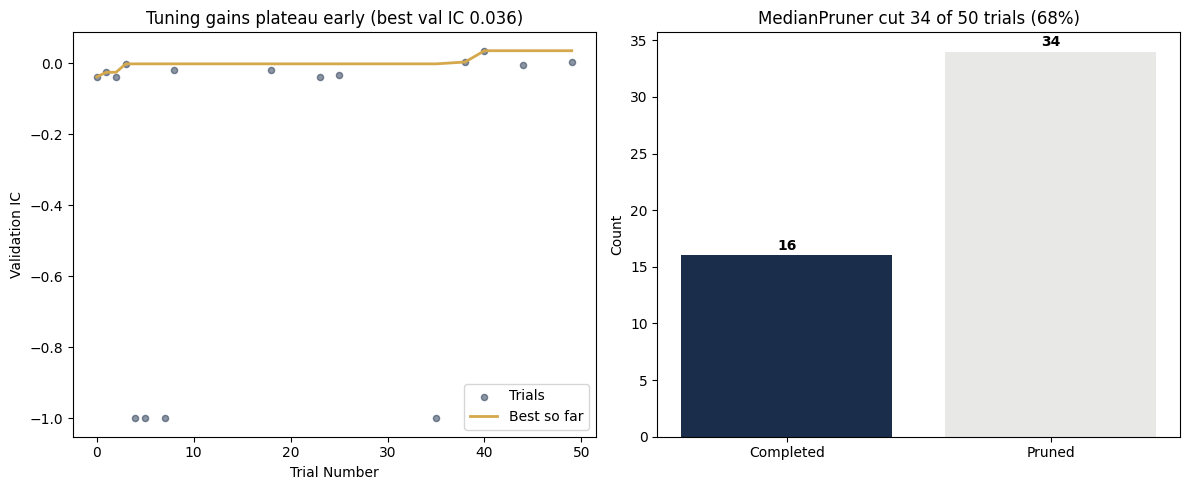

In [11]:
trials_df = study.trials_dataframe()
completed = trials_df[trials_df["state"] == "COMPLETE"].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: trial scatter + best-so-far
ax1 = axes[0]
ax1.scatter(
    completed["number"], completed["value"], s=20, alpha=0.5, color=COLORS["slate"], label="Trials"
)
best_so_far = completed["value"].cummax()
ax1.plot(completed["number"], best_so_far, color=COLORS["amber"], linewidth=2, label="Best so far")
ax1.set_xlabel("Trial Number")
ax1.set_ylabel("Validation IC")
ax1.set_title(f"Tuning gains plateau early (best val IC {study.best_value:.3f})")
ax1.legend()

# Right: pruned vs completed
ax2 = axes[1]
states = ["Completed", "Pruned"]
counts = [n_complete, n_pruned]
colors = [COLORS["slate"], COLORS["silver_muted"]]
ax2.bar(states, counts, color=colors)
ax2.set_ylabel("Count")
ax2.set_title(
    f"MedianPruner cut {n_pruned} of {N_TRIALS} trials ({100 * n_pruned / N_TRIALS:.0f}%)"
)
for i, c in enumerate(counts):
    ax2.text(i, c + 0.5, str(c), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

## 9. Hyperparameter Importance

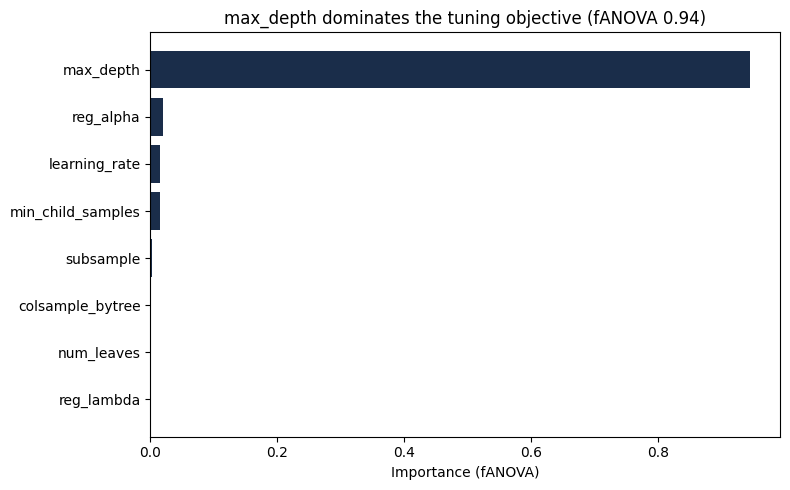

In [12]:
importance = optuna.importance.get_param_importances(study)

fig, ax = plt.subplots(figsize=(8, 5))
params_sorted = list(importance.keys())
values_sorted = list(importance.values())
ax.barh(params_sorted, values_sorted, color=COLORS["slate"])
ax.set_xlabel("Importance (fANOVA)")
ax.set_title(f"{params_sorted[0]} dominates the tuning objective (fANOVA {values_sorted[0]:.2f})")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Interpretation**: fANOVA-based importance decomposes validation IC variance
across hyperparameters. In this single-fold study `max_depth` dominates almost
entirely (fANOVA ≈ 0.94); every other parameter sits near zero, so their
ordering among themselves is noise. The read is that **capping depth** is the
one knob that moves this fold's (thin) IC — once depth is constrained, most
configurations early-stop before the leaf-weight penalties or column/row
sampling can matter. That is a study-specific result, not a law: with a signal
this weak the importance surface is itself noisy, and Section 12.4's general
guidance still holds — fix the learning rate low and let Optuna trade off tree
structure against regularization.

## 10. Time-Series-Aware Tuning: Averaged Walk-Forward HPO

The single-fold study above may overfit to one market period. **Averaged
walk-forward HPO** evaluates each trial across multiple temporal windows,
returning the mean IC as the objective. This is the approach Section 12.4
recommends as the default for financial data.

The computational cost is proportional to the number of folds, but Optuna's
pruning partially offsets this by terminating weak trials early.

In [13]:
def prepare_fold_data(fold_idx):
    """Prepare train/val arrays for a walk-forward fold."""
    split = mds.splits[fold_idx]
    v_end = min(pd.Timestamp(split["val_end"]), val_embargo_cutoff)
    train_m = (df[date_col] >= split["train_start"]) & (df[date_col] <= split["train_end"])
    val_m = (df[date_col] >= split["val_start"]) & (df[date_col] <= v_end)

    X_tr = df.loc[train_m, FEATURE_COLS].values
    y_tr = df.loc[train_m, mds.label_col].values
    X_va = df.loc[val_m, FEATURE_COLS].values
    y_va = df.loc[val_m, mds.label_col].values
    dates_va = df.loc[val_m, date_col].values
    symbols_va = df.loc[val_m, primary_entity_col].values

    v = np.isfinite(y_tr)
    X_tr, y_tr = X_tr[v], y_tr[v]
    v = np.isfinite(y_va)
    X_va, y_va = X_va[v], y_va[v]
    dates_va, symbols_va = dates_va[v], symbols_va[v]
    return X_tr, y_tr, X_va, y_va, dates_va, symbols_va


# Pre-load all fold data to avoid repeated I/O
fold_data = [prepare_fold_data(i) for i in range(n_folds)]
print(f"Prepared {n_folds} walk-forward folds for averaged HPO")

Prepared 8 walk-forward folds for averaged HPO


In [14]:
def walkforward_objective(trial: optuna.Trial) -> float:
    """Averaged walk-forward objective: mean IC across temporal folds."""
    params: dict[str, Any] = {
        "n_estimators": 500,
        "max_depth": trial.suggest_int("max_depth", 2, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 8, 64),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "random_state": SEED,
        "verbose": -1,
        "n_jobs": -1,
    }

    ics = []
    for X_tr, y_tr, X_va, y_va, dates_va, symbols_va in fold_data:
        model = LGBMRegressor(**params)
        model.fit(
            X_tr,
            y_tr,
            eval_set=[(X_va, y_va)],
            callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=0)],
        )
        ic = cross_sectional_ic_mean(y_va, model.predict(X_va), dates_va, symbols_va)
        ics.append(ic if np.isfinite(ic) else -1.0)

    return float(np.mean(ics))

In [15]:
wf_study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=SEED),
)

start_time = time.time()
wf_study.optimize(walkforward_objective, n_trials=N_TRIALS, show_progress_bar=True)
wf_time = time.time() - start_time

print(f"Walk-forward HPO: best mean IC = {wf_study.best_value:.4f}")
print(f"Wall time: {wf_time:.1f}s ({wf_time / study_time:.1f}x single-fold)")

  0%|          | 0/50 [00:00<?, ?it/s]

Walk-forward HPO: best mean IC = -0.0815
Wall time: 462.4s (16.6x single-fold)


### Compare Single-Fold vs Walk-Forward Tuning

The acid test: evaluate both sets of tuned hyperparameters on the held-out
test fold to see which generalizes better.

In [16]:
# Single-fold tuned model (already trained above)
single_test_ic = cross_sectional_ic_mean(
    y_test, tuned_model.predict(X_test), dates_test, symbols_test
)

# Walk-forward tuned model
wf_params: dict[str, Any] = {
    **wf_study.best_params,
    "n_estimators": 500,
    "random_state": SEED,
    "verbose": -1,
    "n_jobs": -1,
}
wf_model = LGBMRegressor(**wf_params)
wf_model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=0)],
)
wf_test_ic = cross_sectional_ic_mean(y_test, wf_model.predict(X_test), dates_test, symbols_test)

tuning_comparison = pl.DataFrame(
    {
        "method": ["Single-fold HPO", "Walk-forward HPO"],
        "best_val_ic": [round(study.best_value, 4), round(wf_study.best_value, 4)],
        "test_ic": [round(single_test_ic, 4), round(wf_test_ic, 4)],
        "wall_time_s": [round(study_time, 1), round(wf_time, 1)],
    }
)
tuning_comparison

method,best_val_ic,test_ic,wall_time_s
str,f64,f64,f64
"""Single-fold HPO""",0.0356,0.1033,27.8
"""Walk-forward HPO""",-0.0815,0.1066,462.4


**Interpretation**: The two objective *values* tell opposite stories from the
two holdout results, and that gap is the lesson. The walk-forward best trial's
averaged objective is negative (mean validation IC −0.082): several folds
degenerate to near-constant predictions — one-tree fits whose cross-sectional
IC is undefined — and the objective penalizes each undefined fold with −1.0, so
the mean is dragged below zero by the degenerate folds rather than by a clean
signal. Yet on the **sealed 2024–2025 holdout** the walk-forward hyperparameters
reach test IC 0.107, edging the single-fold model's 0.103 and clearly above the
untuned default's 0.073. Averaging across regimes is the right instinct: even
with an ugly-looking objective it selects hyperparameters that generalize
marginally better than tuning against one window. But the margins are tiny and
the wall-time cost is real (~20× single-fold here), which is exactly §12.4's
caution — HPO gains on daily-return targets are small and easily swamped by
noise, so pay for walk-forward evaluation only when the compute buys robustness
you can measure.

## Key Takeaways

1. **Early stopping + pruning save compute** — setting `n_estimators` high
   and using `lgb.early_stopping` lets the data determine the tree count,
   while `MedianPruner` (driven by the custom `ICPruningCallback`) terminated
   34 of the 50 single-fold trials early — a 68 % prune rate that scales the
   available compute toward configurations Optuna deems promising.
2. **Evaluate on a sealed holdout, never on a fold the search touched** — the
   test set here is the case study's declared 2024–2025 holdout; all eight
   walk-forward folds precede it, so no Optuna trial ever scored on it. On that
   holdout both tuned configurations beat the untuned default (test IC 0.103
   single-fold and 0.107 walk-forward vs 0.073 default), but the margins are
   thin — a reminder that a "held-out" number is only trustworthy if the search
   could not see it.
3. **Single-fold objectives are noisy and can reward degenerate models** — the
   single-fold "best" trial early-stopped to a one-tree model (`best_iteration_`
   = 1); across the eight folds that same parameter family collapses to
   near-constant predictions on two folds (undefined IC). Walk-forward averaging
   penalizes those degenerate folds (best mean val IC −0.082) and still selects
   hyperparameters that generalize marginally better, but it cannot manufacture
   signal where the target is this noisy — the textbook Box 12.3 caution.
4. **50–100 trials suffice for GBMs** — TPE converges quickly; beyond this
   range, marginal gains are outweighed by validation overfitting risk.

**Next**: See `07_hpo_comparison` for grid search vs Optuna efficiency,
or `06_optuna_multi_asset` for multi-objective IC vs turnover optimization.